# CO2 Emissions Modeling

This notebook implements the full pipeline from [plan.md](plan.md):
1. Load data, time-based splits, scaling, evaluation
2. PCA (scree, loadings, interpretation)
3. Regression (linear, Ridge, Lasso, Elastic Net)
4. Clustering (K-means on PCA scores)
5. Feedforward neural network
6. LSTM for panel time-series
7. GNN (graph from similarity)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# GPU: use if available (for manual PyTorch models)
import torch
# Use CUDA only if available and compatible (e.g. RTX 50xx sm_120 needs newer PyTorch)
if torch.cuda.is_available():
    try:
        torch.zeros(1, device='cuda')
        DEVICE = torch.device('cuda')
    except RuntimeError:
        DEVICE = torch.device('cpu')
        print('CUDA GPU detected but not compatible with this PyTorch build; using CPU.')
        print('  Reason: RTX 50 series (Blackwell/sm_120) needs PyTorch built with CUDA 12.8.')
        print('  To use GPU, install: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128')
else:
    DEVICE = torch.device('cpu')
print('Using device:', DEVICE)
if DEVICE.type == 'cuda':
    print('  GPU:', torch.cuda.get_device_name(0))

DATA_PATH = Path('cleaned_co2_data_20vars.csv')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)

TARGET = 'co2_per_capita'
ID_COLS = ['country', 'year', 'iso_code']
NUMERIC_COLS = [
    'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp',
    'co2', 'co2_per_capita', 'total_ghg', 'consumption_co2', 'methane', 'nitrous_oxide',
    'cement_co2', 'flaring_co2', 'trade_co2', 'coal_co2', 'gas_co2', 'oil_co2'
]
PREDICTOR_COLS = [c for c in NUMERIC_COLS if c != TARGET]

Using device: cuda
  GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Load data, splits, scaling

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Years:', df['year'].min(), '-', df['year'].max())

train = df[(df['year'] >= 1990) & (df['year'] <= 2015)].copy()
val   = df[(df['year'] >= 2016) & (df['year'] <= 2019)].copy()
test  = df[(df['year'] >= 2020) & (df['year'] <= 2022)].copy()
print('Train:', len(train), '| Val:', len(val), '| Test:', len(test))

Shape: (2640, 20)
Years: 1990 - 2022
Train: 2017 | Val: 354 | Test: 269


In [3]:
scaler_X = StandardScaler()
X_train = pd.DataFrame(
    scaler_X.fit_transform(train[PREDICTOR_COLS]),
    columns=PREDICTOR_COLS,
    index=train.index
)
X_val   = pd.DataFrame(scaler_X.transform(val[PREDICTOR_COLS]),   columns=PREDICTOR_COLS, index=val.index)
X_test  = pd.DataFrame(scaler_X.transform(test[PREDICTOR_COLS]),  columns=PREDICTOR_COLS, index=test.index)
y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.size == 0 or y_pred.size == 0:
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }

def metrics_str(d):
    """Format evaluate() dict for easy reading."""
    try:
        r, m, r2 = d['RMSE'], d['MAE'], d['R2']
        if r is None or (hasattr(r, '__float__') and np.isnan(np.float64(r))):
            return 'RMSE=N/A MAE=N/A R2=N/A'
        return f"RMSE={r:.4f} MAE={m:.4f} R2={r2:.4f}"
    except (KeyError, TypeError):
        return 'RMSE=N/A MAE=N/A R2=N/A'

print('Scaling done. Predictors:', len(PREDICTOR_COLS))

Scaling done. Predictors: 16


## 2. PCA

In [4]:
pca = PCA()
pca.fit(X_train)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_85 = np.argmax(cumvar >= 0.85) + 1
print('Components for 85% variance:', n_85)
print('Components for 90% variance:', n_90)

Components for 85% variance: 3
Components for 90% variance: 4


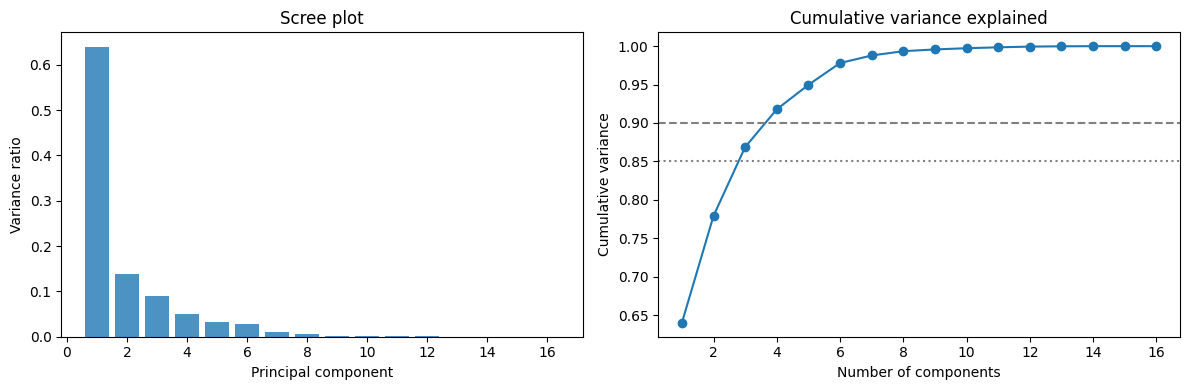

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.8)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance ratio')
axes[0].set_title('Scree plot')
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-')
axes[1].axhline(0.9, color='gray', linestyle='--')
axes[1].axhline(0.85, color='gray', linestyle=':')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative variance explained')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'pca_scree.png', dpi=150)
plt.show()

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=PREDICTOR_COLS
)
print('Loadings (first 5 components):')
display(loadings.iloc[:, :5].round(3))
loadings.to_csv(OUTPUT_DIR / 'tables' / 'pca_loadings.csv')

Loadings (first 5 components):


,PC1,PC2,PC3,PC4,PC5
population,0.235,-0.311,-0.047,0.071,0.564
gdp,0.294,0.130,-0.123,-0.191,-0.018
primary_energy_consumption,0.304,0.116,-0.007,-0.099,-0.159
energy_per_capita,0.017,0.317,0.553,-0.420,0.407
energy_per_gdp,0.022,0.142,0.714,0.229,-0.060
co2,0.308,0.022,0.020,-0.108,-0.180
total_ghg,0.308,-0.006,-0.019,0.000,0.012
consumption_co2,0.304,0.084,-0.028,-0.171,-0.149
methane,0.290,-0.086,-0.052,0.201,0.374
nitrous_oxide,0.294,-0.122,-0.041,0.044,0.306


In [7]:
n_components = max(n_85, 5)
train_scores = pca.transform(X_train)[:, :n_components]
val_scores   = pca.transform(X_val)[:, :n_components]
test_scores  = pca.transform(X_test)[:, :n_components]
print('Using', n_components, 'components for downstream models.')

Using 5 components for downstream models.


## 3. Regression

In [8]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}
results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
        pred = m.predict(X)
        results.append({'model': name, 'split': split_name, **evaluate(y, pred)})
results_df = pd.DataFrame(results)
display(results_df)

,model,split,RMSE,MAE,R2
0,Linear,val,3.566520,1.664840,0.653608
1,Linear,test,3.535777,1.637055,0.619788
2,Ridge,val,3.382289,1.539367,0.688469
3,Ridge,test,3.270271,1.482077,0.674745
4,Lasso,val,3.353151,1.536473,0.693814
5,Lasso,test,3.214860,1.464996,0.685674
6,ElasticNet,val,3.394140,1.559013,0.686283
7,ElasticNet,test,3.140430,1.468256,0.700060


In [9]:
lm = LinearRegression()
lm.fit(X_train, y_train)
coef_df = pd.DataFrame({'predictor': PREDICTOR_COLS, 'coefficient': lm.coef_}).sort_values('coefficient', key=abs, ascending=False)
coef_df.to_csv(OUTPUT_DIR / 'tables' / 'linear_coefficients.csv', index=False)
print('Top predictors (by |coefficient|):')
display(coef_df.head(10))

Top predictors (by |coefficient|):


,predictor,coefficient
5,co2,3.440215e+06
7,consumption_co2,-3.237524e+06
12,trade_co2,4.872009e+05
13,coal_co2,4.450345e+01
2,primary_energy_consumption,-2.809100e+01
15,oil_co2,2.666950e+01
14,gas_co2,1.350125e+01
3,energy_per_capita,7.127519e+00
1,gdp,4.890388e+00
0,population,-2.273436e+00


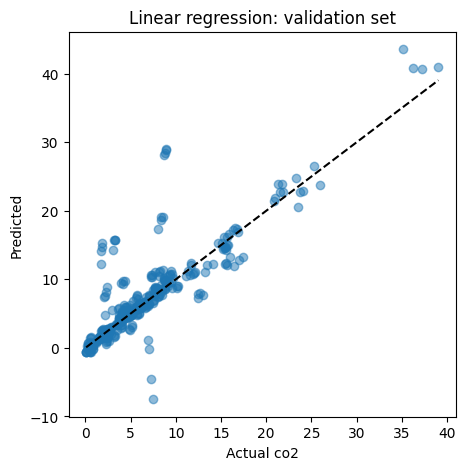

In [10]:
pred_val = lm.predict(X_val)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_val, pred_val, alpha=0.5)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
ax.set_xlabel('Actual co2')
ax.set_ylabel('Predicted')
ax.set_title('Linear regression: validation set')
plt.savefig(OUTPUT_DIR / 'figures' / 'regression_residuals.png', dpi=150)
plt.show()

In [11]:
lm_pca = LinearRegression()
lm_pca.fit(train_scores, y_train)
pred_val_pca = lm_pca.predict(val_scores)
pred_test_pca = lm_pca.predict(test_scores)
print('Regression on PCA scores:')
print('  Val:', evaluate(y_val, pred_val_pca))
print('  Test:', evaluate(y_test, pred_test_pca))

Regression on PCA scores:
  Val: {'RMSE': np.float64(3.5632413869244144), 'MAE': 2.004001715246836, 'R2': 0.6542441521241782}
  Test: {'RMSE': np.float64(3.387448791014157), 'MAE': 1.9839436947195899, 'R2': 0.651018993411538}


## 4. Clustering (K-means on PCA scores)

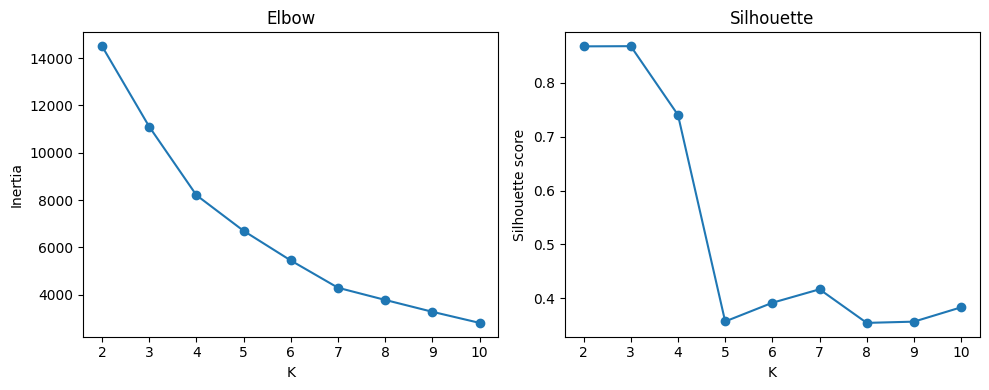

In [12]:
K_range = range(2, 11)
inertias = []
sils = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(train_scores)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(train_scores, lab))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(K_range, inertias, 'o-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow')
axes[1].plot(K_range, sils, 'o-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'clustering_elbow_silhouette.png', dpi=150)
plt.show()

In [13]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train['cluster'] = kmeans.fit_predict(train_scores)
val['cluster']   = kmeans.predict(val_scores)
test['cluster']  = kmeans.predict(test_scores)
summary = train.groupby('cluster')[TARGET].agg(['mean', 'count']).round(4)
summary.to_csv(OUTPUT_DIR / 'tables' / 'cluster_summary.csv')
print('Cluster summary (train set):')
display(summary)

Cluster summary (train set):


,mean,count
cluster,,
0,7.6634,1904
1,5.1414,74
2,19.6081,26
3,5.8351,13


## 5. Feedforward neural network

Device: cuda
Training ManualFFN with config: {'hidden_sizes': (128, 64), 'max_epochs': 500, 'patience': 15, 'lr': 0.001, 'batch_size': 64}
  Epoch 50/500 train_loss=2.8759 val_rmse=1.6972
  Epoch 100/500 train_loss=1.4707 val_rmse=1.3678
  Early stop at epoch 104 (no improvement for 15 epochs)
NN validation: RMSE=1.2778 MAE=0.6469 R2=0.9555
NN test: RMSE=1.2289 MAE=0.6706 R2=0.9541


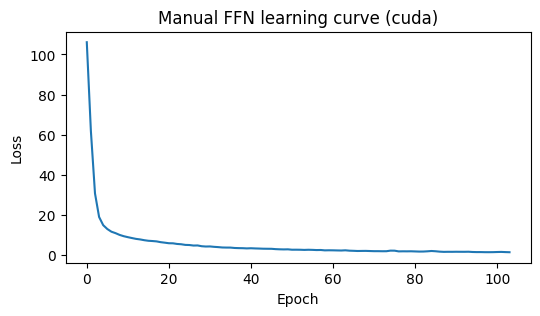

In [14]:
# Manual feedforward NN: config in class, GPU if available
class ManualFFN:
    def __init__(self, hidden_sizes=(128, 64), max_epochs=500, patience=15, lr=1e-3, batch_size=64, device=None, random_state=42):
        self.hidden_sizes = hidden_sizes
        self.max_epochs = max_epochs
        self.patience = patience
        self.lr = lr
        self.batch_size = batch_size
        self.device = device or DEVICE
        self.random_state = random_state
        self.loss_curve_ = []
        self._params = None
        self._n_in = None

    def fit(self, X_tr, y_tr, X_val=None, y_val=None, verbose=True):
        X_tr = X_tr.values if hasattr(X_tr, 'values') else X_tr
        self._n_in = X_tr.shape[1]
        y_tr = y_tr.reshape(-1, 1).astype(np.float32)
        X_t = torch.tensor(X_tr, dtype=torch.float32, device=self.device)
        y_t = torch.tensor(y_tr, device=self.device)
        torch.manual_seed(self.random_state)
        W1 = torch.randn(self._n_in, self.hidden_sizes[0], device=self.device) * 0.1
        b1 = torch.zeros(1, self.hidden_sizes[0], device=self.device)
        W2 = torch.randn(self.hidden_sizes[0], self.hidden_sizes[1], device=self.device) * 0.1
        b2 = torch.zeros(1, self.hidden_sizes[1], device=self.device)
        W3 = torch.randn(self.hidden_sizes[1], 1, device=self.device) * 0.1
        b3 = torch.zeros(1, 1, device=self.device)
        params = [W1, b1, W2, b2, W3, b3]
        for p in params:
            p.requires_grad_(True)
        opt = torch.optim.Adam(params, lr=self.lr)
        self.loss_curve_ = []
        best_val, best_params = float('inf'), None
        no_improve = 0
        n = len(X_t)
        X_v = torch.tensor(X_val.values if hasattr(X_val, 'values') else X_val, dtype=torch.float32, device=self.device) if X_val is not None else None
        y_va = y_val.reshape(-1, 1).astype(np.float32) if y_val is not None else None
        for ep in range(self.max_epochs):
            perm = torch.randperm(n, device=self.device)
            epoch_loss = 0.0
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                x = X_t[idx]
                t = y_t[idx]
                h = torch.relu(x @ W1 + b1)
                h = torch.relu(h @ W2 + b2)
                out = h @ W3 + b3
                loss = ((out - t) ** 2).mean()
                opt.zero_grad()
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * len(idx)
            epoch_loss /= n
            self.loss_curve_.append(epoch_loss)
            if X_v is not None and y_va is not None:
                with torch.no_grad():
                    h = torch.relu(X_v @ W1 + b1)
                    h = torch.relu(h @ W2 + b2)
                    pred_va = (h @ W3 + b3).cpu().numpy().ravel()
                val_mse = mean_squared_error(y_va.ravel(), pred_va)
                if val_mse < best_val:
                    best_val = val_mse
                    best_params = [p.detach().clone() for p in params]
                    no_improve = 0
                else:
                    no_improve += 1
                if verbose and (ep + 1) % 50 == 0:
                    print(f'  Epoch {ep+1}/{self.max_epochs} train_loss={epoch_loss:.4f} val_rmse={np.sqrt(val_mse):.4f}')
                if no_improve >= self.patience:
                    if verbose:
                        print(f'  Early stop at epoch {ep+1} (no improvement for {self.patience} epochs)')
                    break
        if best_params:
            for i, p in enumerate(params):
                p.data.copy_(best_params[i])
        self._params = (W1, b1, W2, b2, W3, b3)
        return self

    def predict(self, X):
        X_ = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32, device=self.device)
        W1, b1, W2, b2, W3, b3 = self._params
        with torch.no_grad():
            h = torch.relu(X_ @ W1 + b1)
            h = torch.relu(h @ W2 + b2)
            return (h @ W3 + b3).cpu().numpy().ravel()

config_ffn = dict(hidden_sizes=(128, 64), max_epochs=500, patience=15, lr=1e-3, batch_size=64)
model_ffn = ManualFFN(**config_ffn)
print('Device:', DEVICE)
print('Training ManualFFN with config:', config_ffn)
model_ffn.fit(X_train, y_train, X_val, y_val)
pred_nn_val = model_ffn.predict(X_val)
pred_nn_test = model_ffn.predict(X_test)
print('NN validation:', metrics_str(evaluate(y_val, pred_nn_val)))
print('NN test:', metrics_str(evaluate(y_test, pred_nn_test)))
plt.figure(figsize=(6, 3))
plt.plot(model_ffn.loss_curve_)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Manual FFN learning curve ({DEVICE.type})')
plt.savefig(OUTPUT_DIR / 'figures' / 'nn_learning_curve.png', dpi=150)
plt.show()


## 6. LSTM (panel time-series)

In [15]:
SEQ_LEN = 5
def build_sequences(df, pred_cols, target_col):
    X_list, y_list = [], []
    for country, g in df.sort_values('year').groupby('country'):
        g = g.sort_values('year')
        arr = g[pred_cols].values
        if len(arr) <= SEQ_LEN:
            continue
        for i in range(SEQ_LEN, len(arr)):
            X_list.append(arr[i-SEQ_LEN:i])
            y_list.append(g[target_col].iloc[i])
    return np.array(X_list), np.array(y_list)

train_full = pd.concat([train, val], ignore_index=True)
train_full[PREDICTOR_COLS] = scaler_X.transform(train_full[PREDICTOR_COLS])
X_seq_train, y_seq_train = build_sequences(train_full, PREDICTOR_COLS, TARGET)
test_scaled = test.copy()
test_scaled[PREDICTOR_COLS] = scaler_X.transform(test[PREDICTOR_COLS])
X_seq_test, y_seq_test = build_sequences(test_scaled, PREDICTOR_COLS, TARGET)
print('Train sequences:', X_seq_train.shape)
print('Test sequences:', X_seq_test.shape)

Train sequences: (1925, 5, 16)
Test sequences: (0,)


LSTM train (1990-2013): (1416, 5, 16)
LSTM test (holdout 2014-2019): (86, 5, 16)
Device: cuda
Training ManualLSTMRegressor with config: {'n_in': 16, 'hidden_size': 64, 'max_epochs': 200, 'patience': 3, 'lr': 0.001, 'batch_size': 32}
  Epoch 1/200 loss=111.0918 val_rmse=8.0652
  Epoch 5/200 loss=33.2814 val_rmse=4.2007
  Epoch 10/200 loss=21.0301 val_rmse=3.3909
  Epoch 15/200 loss=13.7352 val_rmse=2.4654
  Epoch 20/200 loss=10.2971 val_rmse=1.9712
  Epoch 25/200 loss=7.9799 val_rmse=2.1629
  Epoch 30/200 loss=6.0998 val_rmse=1.8770
  Early stop at epoch 32 (no improvement for 3 epochs)
LSTM test: RMSE=1.7431 MAE=1.0777 R2=0.9147


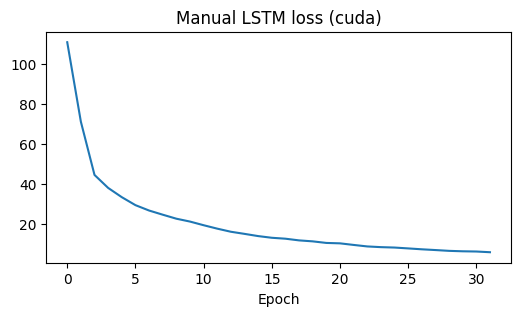

In [16]:
# Manual LSTM (no Keras): implement LSTM cell and train with progress; use GPU if available
if X_seq_test.shape[0] == 0:
    # Need >= SEQ_LEN+1 years per country; hold out 2014-2019 for LSTM test, train on 1990-2013
    train_full_early = train_full[train_full['year'] < 2014]
    train_full_late  = train_full[train_full['year'] >= 2014]
    X_seq_train, y_seq_train = build_sequences(train_full_early, PREDICTOR_COLS, TARGET)
    X_seq_test,  y_seq_test  = build_sequences(train_full_late,  PREDICTOR_COLS, TARGET)
    print('LSTM train (1990-2013):', X_seq_train.shape)
    print('LSTM test (holdout 2014-2019):', X_seq_test.shape)
else:
    print('LSTM train sequences:', X_seq_train.shape)
    print('LSTM test sequences:', X_seq_test.shape)

# Manual LSTM: config in class
class ManualLSTM(torch.nn.Module):
    def __init__(self, n_in, hidden_size, device):
        super().__init__()
        self.hidden_size = hidden_size
        self.device = device
        self.W_i = torch.nn.Parameter(torch.randn(n_in + hidden_size, hidden_size, device=device) * 0.1)
        self.W_f = torch.nn.Parameter(torch.randn(n_in + hidden_size, hidden_size, device=device) * 0.1)
        self.W_c = torch.nn.Parameter(torch.randn(n_in + hidden_size, hidden_size, device=device) * 0.1)
        self.W_o = torch.nn.Parameter(torch.randn(n_in + hidden_size, hidden_size, device=device) * 0.1)
        self.fc = torch.nn.Linear(hidden_size, 1).to(device)
    def forward(self, x):
        if x.dim() == 1:
            return torch.empty(0, device=x.device)
        if x.dim() == 2:
            x = x.unsqueeze(0)
        batch, seq_len, _ = x.shape
        h = torch.zeros(batch, self.hidden_size, device=x.device)
        c = torch.zeros(batch, self.hidden_size, device=x.device)
        for t in range(seq_len):
            xt = x[:, t]
            inp = torch.cat([xt, h], dim=1)
            i = torch.sigmoid(inp @ self.W_i)
            f = torch.sigmoid(inp @ self.W_f)
            c_tilde = torch.tanh(inp @ self.W_c)
            c = f * c + i * c_tilde
            o = torch.sigmoid(inp @ self.W_o)
            h = o * torch.tanh(c)
        return self.fc(h).squeeze(-1)

class ManualLSTMRegressor:
    def __init__(self, n_in, hidden_size=64, max_epochs=200, patience=3, lr=1e-3, batch_size=32, device=None, random_state=42):
        self.n_in = n_in
        self.hidden_size = hidden_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.lr = lr
        self.batch_size = batch_size
        self.device = device or DEVICE
        self.random_state = random_state
        self.loss_curve_ = []
        self.model_ = None

    def fit(self, X_seq, y_seq, X_val=None, y_val=None, verbose=True):
        torch.manual_seed(self.random_state)
        self.model_ = ManualLSTM(self.n_in, self.hidden_size, self.device)
        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        X_t = torch.tensor(X_seq, dtype=torch.float32, device=self.device)
        y_t = torch.tensor(y_seq, dtype=torch.float32, device=self.device)
        n = len(X_t)
        self.loss_curve_ = []
        have_val = (X_val is not None and y_val is not None and
                   hasattr(X_val, 'shape') and len(X_val.shape) == 3 and X_val.shape[0] > 0)
        best_score = np.inf
        best_state = None
        no_improve = 0
        for ep in range(self.max_epochs):
            perm = torch.randperm(n, device=self.device)
            epoch_loss = 0.0
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                pred = self.model_(X_t[idx])
                loss = ((pred - y_t[idx]) ** 2).mean()
                opt.zero_grad()
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * len(idx)
            epoch_loss /= n
            self.loss_curve_.append(epoch_loss)
            if have_val:
                with torch.no_grad():
                    X_v = torch.tensor(X_val, dtype=torch.float32, device=self.device)
                    te_pred = self.model_(X_v).cpu().numpy()
                score = np.sqrt(mean_squared_error(y_val, te_pred))
                if score < best_score:
                    best_score = score
                    best_state = [p.clone() for p in self.model_.parameters()]
                    no_improve = 0
                else:
                    no_improve += 1
                if verbose and ((ep + 1) % 5 == 0 or ep == 0):
                    print(f'  Epoch {ep+1}/{self.max_epochs} loss={epoch_loss:.4f} val_rmse={score:.4f}')
            else:
                if epoch_loss < best_score:
                    best_score = epoch_loss
                    best_state = [p.clone() for p in self.model_.parameters()]
                    no_improve = 0
                else:
                    no_improve += 1
                if verbose and ((ep + 1) % 5 == 0 or ep == 0):
                    print(f'  Epoch {ep+1}/{self.max_epochs} loss={epoch_loss:.4f}')
            if no_improve >= self.patience:
                if verbose:
                    print(f'  Early stop at epoch {ep+1} (no improvement for {self.patience} epochs)')
                break
        if best_state is not None:
            for p, state in zip(self.model_.parameters(), best_state):
                p.data.copy_(state)
        return self

    def predict(self, X_seq):
        if hasattr(X_seq, 'shape') and (len(X_seq.shape) < 3 or X_seq.shape[0] == 0):
            return np.array([])
        X_t = torch.tensor(X_seq, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            return self.model_(X_t).cpu().numpy()

config_lstm = dict(n_in=len(PREDICTOR_COLS), hidden_size=64, max_epochs=200, patience=3, lr=1e-3, batch_size=32)
model_lstm = ManualLSTMRegressor(**config_lstm)
print('Device:', DEVICE)
print('Training ManualLSTMRegressor with config:', config_lstm)
model_lstm.fit(X_seq_train, y_seq_train, X_seq_test, y_seq_test)
pred_lstm = model_lstm.predict(X_seq_test)
if len(y_seq_test) > 0 and len(pred_lstm) > 0:
    print('LSTM test:', metrics_str(evaluate(y_seq_test, pred_lstm)))
else:
    print('LSTM test: (no test sequences — metrics N/A)')
plt.figure(figsize=(6, 3))
if len(model_lstm.loss_curve_) > 0:
    plt.plot(model_lstm.loss_curve_)
plt.xlabel('Epoch')
plt.title(f'Manual LSTM loss ({DEVICE.type})')
plt.savefig(OUTPUT_DIR / 'figures' / 'lstm_learning_curve.png', dpi=150)
plt.show()


## 7. GNN

Build a graph: nodes = country-year or countries; edges from similarity (e.g. correlation of emissions over time). Then use a simple graph-aware model. Here we construct the graph and fit a baseline (mean neighbor features) as a placeholder; a full GCN would require PyTorch Geometric.

In [17]:
country_means = df.groupby('country')[PREDICTOR_COLS + [TARGET]].mean()
corr = country_means[PREDICTOR_COLS].T.corr().fillna(0).values
np.fill_diagonal(corr, 0)
threshold = 0.5
adj = (np.abs(corr) >= threshold).astype(np.float32)
print('Graph: nodes = countries, edges = |correlation| >=', threshold)
print('Edges:', int(adj.sum().sum()//2))


Graph: nodes = countries, edges = |correlation| >= 0.5
Edges: 4095


Device: cuda
Training ManualGCN with config: {'n_feat': 16, 'hidden_size': 32, 'max_epochs': 200, 'patience': 15, 'lr': 0.01}
  Epoch 50/200 loss=83.5821 R2=-0.5865
  Epoch 100/200 loss=59.3546 R2=-0.1215
  Epoch 150/200 loss=35.1088 R2=0.3375
  Epoch 200/200 loss=23.6285 R2=0.5516
GNN (country-level) R2: 0.5516


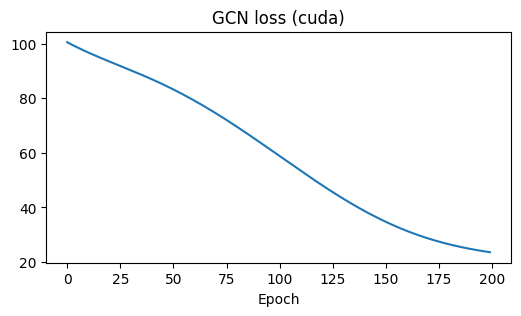

GNN mapped to test (by country): RMSE=3.6132 MAE=2.3399 R2=0.6029


In [18]:
# Manual GCN: config in class; 2-layer message passing then regression
from scipy.sparse import csr_matrix

class ManualGCN:
    """2-layer GCN: H1 = relu(A_norm @ X @ W1), H2 = A_norm @ H1, out = H2 @ W2."""
    def __init__(self, n_feat, hidden_size=32, max_epochs=200, patience=15, lr=0.01, device=None, random_state=42):
        self.n_feat = n_feat
        self.hidden_size = hidden_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.lr = lr
        self.device = device or DEVICE
        self.random_state = random_state
        self.loss_curve_ = []
        self._W1 = self._W2 = self._W_skip = None

    def fit(self, A_norm, X, y, verbose=True):
        torch.manual_seed(self.random_state)
        A_t = torch.tensor(A_norm, dtype=torch.float32, device=self.device)
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        y_t = torch.tensor(y, dtype=torch.float32, device=self.device)
        self._W1 = torch.randn(self.n_feat, self.hidden_size, device=self.device) * 0.1
        self._W2 = torch.randn(self.hidden_size, 1, device=self.device) * 0.1
        self._W1.requires_grad_(True)
        self._W2.requires_grad_(True)
        self._W_skip = torch.randn(self.n_feat, 1, device=self.device) * 0.01
        self._W_skip.requires_grad_(True)
        opt = torch.optim.Adam([self._W1, self._W2, self._W_skip], lr=self.lr)
        self.loss_curve_ = []
        best_loss = float('inf')
        no_improve = 0
        for ep in range(self.max_epochs):
            H = torch.relu(A_t @ X_t @ self._W1)
            H = A_t @ H
            graph_out = H @ self._W2
            skip_out = X_t @ self._W_skip
            out = graph_out + skip_out
            loss = ((out - y_t) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            self.loss_curve_.append(loss.item())
            if loss.item() < best_loss:
                best_loss = loss.item()
                no_improve = 0
            else:
                no_improve += 1
            if verbose and (ep + 1) % 50 == 0:
                pred = self.predict(A_norm, X)
                print(f'  Epoch {ep+1}/{self.max_epochs} loss={loss.item():.4f} R2={r2_score(y.ravel(), pred):.4f}')
            if no_improve >= self.patience:
                if verbose:
                    print(f'  Early stop at epoch {ep+1} (no improvement for {self.patience} epochs)')
                break
        return self

    def predict(self, A_norm, X):
        A_t = torch.tensor(A_norm, dtype=torch.float32, device=self.device)
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            H = torch.relu(A_t @ X_t @ self._W1)
            H = A_t @ H
            graph_out = H @ self._W2
            skip_out = X_t @ self._W_skip
            out = (graph_out + skip_out).cpu().numpy().ravel()
        return out

A = csr_matrix(adj)
row_sum = np.array(A.sum(axis=1)).flatten()
row_sum[row_sum == 0] = 1
D_inv = np.diag(1.0 / row_sum)
A_norm = D_inv @ A.toarray()
X_country = country_means[PREDICTOR_COLS].values.astype(np.float32)
X_scaled = StandardScaler().fit_transform(X_country)
y_country = country_means[TARGET].values.astype(np.float32).reshape(-1, 1)
n_nodes, n_feat = X_scaled.shape
config_gnn = dict(n_feat=n_feat, hidden_size=32, max_epochs=200, patience=15, lr=0.01)
model_gnn = ManualGCN(**config_gnn)
print('Device:', DEVICE)
print('Training ManualGCN with config:', config_gnn)
model_gnn.fit(A_norm, X_scaled, y_country)
pred_gnn_country = model_gnn.predict(A_norm, X_scaled)
print('GNN (country-level) R2:', round(r2_score(y_country.ravel(), pred_gnn_country), 4))
plt.figure(figsize=(6, 3))
plt.plot(model_gnn.loss_curve_)
plt.xlabel('Epoch')
plt.title(f'GCN loss ({DEVICE.type})')
plt.savefig(OUTPUT_DIR / 'figures' / 'gnn_learning_curve.png', dpi=150)
plt.show()
gnn_by_country = dict(zip(country_means.index, pred_gnn_country))
test['_gnn_pred'] = test['country'].map(gnn_by_country)
pred_gnn_test = test['_gnn_pred'].values
if np.isnan(pred_gnn_test).any():
    pred_gnn_test = np.nan_to_num(pred_gnn_test, nan=np.nanmean(pred_gnn_country))
print('GNN mapped to test (by country):', metrics_str(evaluate(y_test, pred_gnn_test)))


## Summary: model comparison

In [19]:
comparison = []
for name, pred in [
    ('Linear', lm.predict(X_test)),
    ('Ridge', models['Ridge'].predict(X_test)),
    ('Lasso', models['Lasso'].predict(X_test)),
    ('ElasticNet', models['ElasticNet'].predict(X_test)),
    ('PCA+Linear', lm_pca.predict(test_scores)),
    ('Manual NN', model_ffn.predict(X_test)),
]:
    comparison.append({'model': name, **evaluate(y_test, pred)})
try:
    if len(y_seq_test) > 0:
        comparison.append({'model': 'LSTM', **evaluate(y_seq_test, pred_lstm)})
except NameError:
    pass
try:
    comparison.append({'model': 'GNN', **evaluate(y_test, pred_gnn_test)})
except NameError:
    pass
comp_df = pd.DataFrame(comparison)
comp_df.to_csv(OUTPUT_DIR / 'tables' / 'model_comparison.csv', index=False)
display(comp_df)
best_idx = comp_df['R2'].idxmax()
print('Best model by R2:', comp_df.loc[best_idx, 'model'], '(R2 =', round(comp_df.loc[best_idx, 'R2'], 4), ')')
best_rmse = comp_df['RMSE'].idxmin()
print('Best model by RMSE:', comp_df.loc[best_rmse, 'model'], '(RMSE =', round(comp_df.loc[best_rmse, 'RMSE'], 4), ')')


,model,RMSE,MAE,R2
0,Linear,3.535777,1.637055,0.619788
1,Ridge,3.270271,1.482077,0.674745
2,Lasso,3.214860,1.464996,0.685674
3,ElasticNet,3.140430,1.468256,0.700060
4,PCA+Linear,3.387449,1.983944,0.651019
5,Manual NN,1.228948,0.670641,0.954067
6,LSTM,1.743074,1.077667,0.914715
7,GNN,3.613236,2.339912,0.602946


Best model by R2: Manual NN (R2 = 0.9541 )
Best model by RMSE: Manual NN (RMSE = 1.2289 )


## CSV-derived visualizations

Generate PNGs from the saved tables so all outputs are produced by the notebook.

In [20]:
def plot_pca_loadings(tables_dir, figures_dir):
    path = tables_dir / 'pca_loadings.csv'
    if not path.is_file():
        return
    df = pd.read_csv(path, index_col=0).astype(float)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(df.values, cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    plt.colorbar(im, ax=ax, label='Loading')
    ax.set_title('PCA loadings (variables × components)')
    plt.tight_layout()
    plt.savefig(figures_dir / 'pca_loadings_heatmap.png', bbox_inches='tight')
    plt.close()
    print('Saved pca_loadings_heatmap.png')

def plot_linear_coefficients(tables_dir, figures_dir):
    path = tables_dir / 'linear_coefficients.csv'
    if not path.is_file():
        return
    df = pd.read_csv(path)
    if 'predictor' not in df.columns or 'coefficient' not in df.columns:
        return
    df = df.sort_values('coefficient', key=abs, ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = np.where(df['coefficient'] >= 0, 'steelblue', 'coral')
    ax.barh(df['predictor'], df['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient')
    ax.set_title('Linear regression coefficients (OLS on scaled features)\nLarge magnitudes can indicate multicollinearity')
    plt.tight_layout()
    plt.savefig(figures_dir / 'linear_coefficients.png', bbox_inches='tight')
    plt.close()
    print('Saved linear_coefficients.png')

def plot_cluster_summary(tables_dir, figures_dir):
    path = tables_dir / 'cluster_summary.csv'
    if not path.is_file():
        return
    df = pd.read_csv(path)
    if 'cluster' not in df.columns:
        return
    df['cluster'] = df['cluster'].astype(str)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.bar(df['cluster'], df['mean'], color='teal', alpha=0.8)
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Mean co2')
    ax1.set_title('Mean target by cluster')
    ax2.bar(df['cluster'], df['count'], color='mediumpurple', alpha=0.8)
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Count')
    ax2.set_title('Sample count by cluster')
    plt.tight_layout()
    plt.savefig(figures_dir / 'cluster_summary.png', bbox_inches='tight')
    plt.close()
    print('Saved cluster_summary.png')

def plot_model_comparison(tables_dir, figures_dir):
    path = tables_dir / 'model_comparison.csv'
    if not path.is_file():
        return
    df = pd.read_csv(path)
    if 'model' not in df.columns:
        return
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, col, title in zip(axes, ['RMSE', 'MAE', 'R2'], ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)']):
        ax.bar(df['model'], df[col], color='forestgreen', alpha=0.7)
        ax.set_xticklabels(df['model'], rotation=45, ha='right')
        ax.set_ylabel(col)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(figures_dir / 'model_comparison.png', bbox_inches='tight')
    plt.close()
    print('Saved model_comparison.png')

# Run all CSV-derived visualizations (uses OUTPUT_DIR from notebook)
_tables = OUTPUT_DIR / 'tables'
_figures = OUTPUT_DIR / 'figures'
plot_pca_loadings(_tables, _figures)
plot_linear_coefficients(_tables, _figures)
plot_cluster_summary(_tables, _figures)
plot_model_comparison(_tables, _figures)

Saved pca_loadings_heatmap.png
Saved linear_coefficients.png
Saved cluster_summary.png
Saved model_comparison.png
